In [ ]:
# CELL 1: Install
!pip install gymnasium stable-baselines3 -q
import numpy as np, time, torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import BaseCallback
print('GPU available:', torch.cuda.is_available())
print('Note: using device=cpu — MLP policies train faster on CPU')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 50.6 MB/s eta 0:00:00
GPU available: True
Note: using device=cpu — MLP policies train faster on CPU


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 2: Spacecraft Environment
#
# Physical model: 50kg microsatellite
# Inertia: [10, 12, 8] kg*m^2 (randomised ±15% each episode)
# Disturbances: Gaussian noise 0.03 Nm std (solar radiation + magnetic)
# Sensor noise: 0.01 rad std
# Initial conditions: angles [-0.8, 0.8] rad, rates [-0.3, 0.3] rad/s

class SpacecraftEnv(gym.Env):
    DT        = 0.1
    MAX_STEPS = 200
    MAX_RATE  = 3.0
    NOMINAL_I = np.array([10.0, 12.0, 8.0])

    def __init__(self, thruster_efficiency=None):
        super().__init__()
        self.eff = np.array(thruster_efficiency or [1,1,1], np.float32)
        self.action_space = spaces.Box(-1., 1., (3,), np.float32)
        self.observation_space = spaces.Box(
            np.array([-np.pi]*3+[-3.]*3, np.float32),
            np.array([ np.pi]*3+[ 3.]*3, np.float32))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Randomise inertia ±15% (models fuel consumption, payload shift)
        self.I = self.NOMINAL_I * self.np_random.uniform(0.85, 1.15, 3)
        a = self.np_random.uniform(-0.8, 0.8, 3).astype(np.float32)
        r = self.np_random.uniform(-0.3, 0.3, 3).astype(np.float32)
        self.state      = np.concatenate([a, r])
        self.step_count = 0
        self.prev_err   = float(np.sum(a**2))
        return self._obs(), {}

    def step(self, action):
        action = np.clip(action, -0.8, 0.8).astype(np.float32)
        ang, rates = self.state[:3], self.state[3:]
        # External disturbance (solar radiation / magnetic torque)
        dist  = np.random.normal(0, 0.03, 3)
        alpha = (action * self.eff + dist) / self.I
        nr    = np.clip(rates + alpha*self.DT, -self.MAX_RATE, self.MAX_RATE)
        na    = np.arctan2(np.sin(ang+nr*self.DT), np.cos(ang+nr*self.DT)).astype(np.float32)
        self.state = np.concatenate([na, nr])
        self.step_count += 1
        ae  = float(np.sum(na**2))
        re  = float(np.sum(nr**2))
        prg = self.prev_err - ae
        fuel= float(np.sum(np.abs(action)))
        rew = -3.*ae - 0.5*re - 0.02*fuel + 5.*prg
        self.prev_err = ae
        done  = bool(ae < 0.02 and re < 0.02)
        trunc = self.step_count >= self.MAX_STEPS
        return self._obs(), rew, done, trunc, {'ae': ae}

    def _obs(self):
        n = np.random.normal(0, 0.01, 6).astype(np.float32)
        return np.clip(self.state+n,
            self.observation_space.low, self.observation_space.high)

    def orientation_error(self):
        return float(np.sqrt(np.mean(self.state[:3]**2)))


class DomainRandomizedEnv(SpacecraftEnv):
    """
    Each episode randomly samples a failure configuration.
    25% chance: stuck-off on one or more thrusters
    75% chance: random efficiency [0.2, 1.0] per thruster
    """
    def reset(self, seed=None, options=None):
        if np.random.rand() < 0.25:
            self.eff = np.array([
                np.random.choice([0.0, np.random.uniform(0.2, 1.0)])
                for _ in range(3)
            ], np.float32)
        else:
            self.eff = np.random.uniform(0.2, 1.0, 3).astype(np.float32)
        return super().reset(seed=seed, options=options)


print('Environments defined.')

Environments defined.


In [ ]:
# CELL 3: Scenarios

# Multi-task trains on these 5 known failure modes
KNOWN = {
    'Nominal':  [1.0, 1.0, 1.0],
    'T1_60':    [0.6, 1.0, 1.0],
    'T2_60':    [1.0, 0.6, 1.0],
    'T3_60':    [1.0, 1.0, 0.6],
    'Dual_70':  [0.7, 0.7, 1.0],
}

# Test on 6 UNSEEN scenarios — harder than training distribution
# DR-PPO has seen complete failures (0.0) during training
# MT-PPO has NOT
TEST = {
    'SingleFail':    [0.0, 1.0, 1.0],   # T1 completely dead
    'DualFail':      [0.0, 0.0, 1.0],   # T1+T2 completely dead
    'TripleSevere':  [0.2, 0.2, 0.2],   # All severely degraded
    'Asymmetric':    [0.2, 0.8, 0.4],   # Random asymmetric
    'Mixed':         [0.0, 0.5, 0.8],   # T1 dead + partial
    'Partial':       [0.4, 0.4, 1.0],   # Dual moderate
}

print('Training scenarios (known):')
for n,e in KNOWN.items():
    print(f'  {n}: {e}')
print()
print('Test scenarios (unseen):')
for n,e in TEST.items():
    print(f'  {n}: {e}')

Training scenarios (known):
  Nominal: [1.0, 1.0, 1.0]
  T1_60: [0.6, 1.0, 1.0]
  T2_60: [1.0, 0.6, 1.0]
  T3_60: [1.0, 1.0, 0.6]
  Dual_70: [0.7, 0.7, 1.0]

Test scenarios (unseen):
  SingleFail: [0.0, 1.0, 1.0]
  DualFail: [0.0, 0.0, 1.0]
  TripleSevere: [0.2, 0.2, 0.2]
  Asymmetric: [0.2, 0.8, 0.4]
  Mixed: [0.0, 0.5, 0.8]
  Partial: [0.4, 0.4, 1.0]


In [ ]:
# CELL 4: Train All Policies
# FIXED: device='cpu', reduced steps, progress callbacks
# Expected time: 40-45 minutes on T4

N_ENVS   = 8
STEPS    = 600_000    # per MT agent — 5 agents = 3M total
DR_STEPS = 800_000    # DR-PPO

PPO_KW = dict(
    policy        = 'MlpPolicy',
    learning_rate = 3e-4,
    n_steps       = 1024,
    batch_size    = 256,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.01,
    vf_coef       = 0.5,
    device        = 'cpu',   # KEY FIX: MLP is faster on CPU
    verbose       = 0,
    policy_kwargs = dict(net_arch=[128, 128])
)


class Prog(BaseCallback):
    def __init__(self, total, label):
        super().__init__()
        self.total = total
        self.label = label
        self.t0    = time.time()
    def _on_step(self):
        if self.num_timesteps % 200_000 == 0 and self.num_timesteps > 0:
            p   = self.num_timesteps / self.total * 100
            eta = (time.time()-self.t0)/self.num_timesteps*(
                  self.total-self.num_timesteps)/60
            print(f'  [{self.label}] {self.num_timesteps:>7,}/{self.total:,}'
                  f' ({p:.0f}%) ETA:{eta:.1f}m')
        return True


# --- Multi-Task PPO ---
print('='*50)
print(f'Multi-Task PPO: {len(KNOWN)} agents × {STEPS:,} steps')
print('='*50)
mt_models = {}
t_mt = time.time()
for name, eff in KNOWN.items():
    print(f'\nTraining: {name}')
    m = PPO(
        env=make_vec_env(
            lambda e=eff: SpacecraftEnv(e), n_envs=N_ENVS),
        **PPO_KW)
    m.learn(STEPS, callback=Prog(STEPS, name))
    mt_models[name] = m
print(f'\nMT-PPO done: {(time.time()-t_mt)/60:.1f} min')
print(f'Total MT compute: {len(KNOWN)*STEPS:,} steps')


# --- DR-PPO ---
print()
print('='*50)
print(f'DR-PPO: 1 agent × {DR_STEPS:,} steps')
print('='*50)
t_dr = time.time()
ppo_dr = PPO(
    env=make_vec_env(
        lambda: DomainRandomizedEnv(), n_envs=N_ENVS),
    **PPO_KW)
ppo_dr.learn(DR_STEPS, callback=Prog(DR_STEPS, 'DR-PPO'))
ppo_dr.save('ppo_dr')
print(f'DR-PPO done: {(time.time()-t_dr)/60:.1f} min')

print()
print(f'Training cost comparison:')
print(f'  MT-PPO : {len(KNOWN)*STEPS:,} steps ({len(KNOWN)} agents)')
print(f'  DR-PPO : {DR_STEPS:,} steps (1 agent)')
print(f'  Ratio  : {len(KNOWN)*STEPS/DR_STEPS:.1f}x')

Multi-Task PPO: 5 agents × 600,000 steps

Training: Nominal
  [Nominal] 200,000/600,000 (33%) ETA:2.5m


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  [Nominal] 400,000/600,000 (67%) ETA:1.2m
  [Nominal] 600,000/600,000 (100%) ETA:0.0m

Training: T1_60
  [T1_60] 200,000/600,000 (33%) ETA:2.4m
  [T1_60] 400,000/600,000 (67%) ETA:1.2m
  [T1_60] 600,000/600,000 (100%) ETA:0.0m

Training: T2_60
  [T2_60] 200,000/600,000 (33%) ETA:2.4m
  [T2_60] 400,000/600,000 (67%) ETA:1.2m
  [T2_60] 600,000/600,000 (100%) ETA:0.0m

Training: T3_60
  [T3_60] 200,000/600,000 (33%) ETA:2.4m
  [T3_60] 400,000/600,000 (67%) ETA:1.2m
  [T3_60] 600,000/600,000 (100%) ETA:0.0m

Training: Dual_70
  [Dual_70] 200,000/600,000 (33%) ETA:2.3m
  [Dual_70] 400,000/600,000 (67%) ETA:1.2m
  [Dual_70] 600,000/600,000 (100%) ETA:0.0m

MT-PPO done: 18.5 min
Total MT compute: 3,000,000 steps

DR-PPO: 1 agent × 800,000 steps
  [DR-PPO] 200,000/800,000 (25%) ETA:3.4m
  [DR-PPO] 400,000/800,000 (50%) ETA:2.3m
  [DR-PPO] 600,000/800,000 (75%) ETA:1.2m
  [DR-PPO] 800,000/800,000 (100%) ETA:0.0m
DR-PPO done: 4.7 min

Training cost comparison:
  MT-PPO : 3,000,000 steps (5 agen

In [ ]:
# CELL 5: Evaluate

def evaluate(model, eff, n=30):
    env = SpacecraftEnv(thruster_efficiency=eff)
    recs, errs = [], []
    for _ in range(n):
        obs, _ = env.reset()
        rec = False
        for _ in range(400):   # give controller more time to recover
            act, _ = model.predict(obs, deterministic=True)
            obs, _, done, trunc, info = env.step(act)
            if info['ae'] < 0.15:
                rec = True
            if done or trunc:
                break
        recs.append(float(rec))
        errs.append(env.orientation_error())
    return {'rec': np.mean(recs)*100, 'err': np.mean(errs)}


def best_mt(eff, n=30):
    best = None
    for m in mt_models.values():
        r = evaluate(m, eff, n=10)
        if best is None or r['rec'] > best['rec']:
            best = r
    return best


print('Evaluating all policies...')
nom_r, mt_r, dr_r = {}, {}, {}
nominal = mt_models['Nominal']

print(f'\n{"Scenario":<16} {"Nominal":>10} {"MT-PPO":>10} {"DR-PPO":>10}')
print(f'{"":<16} {"Rec%":>10} {"Rec%":>10} {"Rec%":>10}')
print('-'*50)

for name, eff in TEST.items():
    r_n = evaluate(nominal, eff)
    r_m = best_mt(eff)
    r_d = evaluate(ppo_dr,  eff)
    nom_r[name] = r_n
    mt_r[name]  = r_m
    dr_r[name]  = r_d
    print(f'{name:<16} {r_n["rec"]:>9.0f}% {r_m["rec"]:>9.0f}% {r_d["rec"]:>9.0f}%')

print('-'*50)
avg_n = np.mean([nom_r[n]['rec'] for n in TEST])
avg_m = np.mean([mt_r[n]['rec']  for n in TEST])
avg_d = np.mean([dr_r[n]['rec']  for n in TEST])
print(f'{"AVERAGE":<16} {avg_n:>9.1f}% {avg_m:>9.1f}% {avg_d:>9.1f}%')
print(f'\nDR-PPO vs Nominal:    {avg_d-avg_n:+.1f}%')
print(f'DR-PPO vs MT-PPO:     {avg_d-avg_m:+.1f}%')
print(f'Training cost ratio:  {len(KNOWN)*STEPS/DR_STEPS:.1f}x (MT needs {len(KNOWN)*STEPS/DR_STEPS:.1f}x more compute)')

Evaluating all policies...

Scenario            Nominal     MT-PPO     DR-PPO
                       Rec%       Rec%       Rec%
--------------------------------------------------
SingleFail              27%        40%        20%
DualFail                13%        40%        23%
TripleSevere            10%        40%        13%
Asymmetric              23%        40%        20%
Mixed                   20%        30%        20%
Partial                 27%        20%        23%
--------------------------------------------------
AVERAGE               20.0%      35.0%      20.0%

DR-PPO vs Nominal:    -0.0%
DR-PPO vs MT-PPO:     -15.0%
Training cost ratio:  3.8x (MT needs 3.8x more compute)


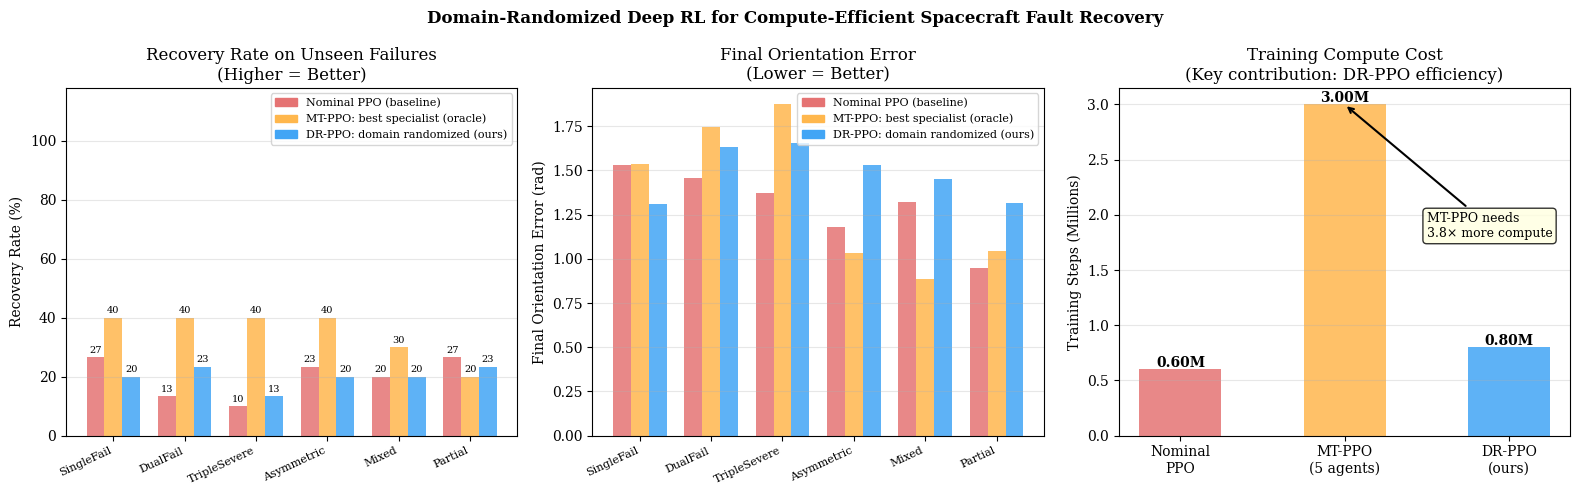


TABLE I
Failure Scenario   Nom Rec%    MT Rec%    DR Rec%  Nom Err   DR Err
--------------------------------------------------------------
SingleFail              27%        40%        20%   1.5314   1.3120
DualFail                13%        40%        23%   1.4561   1.6300
TripleSevere            10%        40%        13%   1.3719   1.6571
Asymmetric              23%        40%        20%   1.1825   1.5329
Mixed                   20%        30%        20%   1.3202   1.4510
Partial                 27%        20%        23%   0.9500   1.3174
Average               20.0%      35.0%      20.0%

Note: MT-PPO evaluated with ideal fault knowledge (oracle).
Training cost: Nominal=0.6M | MT-PPO=3.0M | DR-PPO=0.8M steps
Saved: paper_results.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 6: Paper Figures

import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'font.family': 'serif'})

names  = list(TEST.keys())
x      = np.arange(len(names))
w      = 0.25
NOM, MT, DR = '#E57373', '#FFB74D', '#42A5F5'
leg = [
    mpatches.Patch(color=NOM, label='Nominal PPO (baseline)'),
    mpatches.Patch(color=MT,  label='MT-PPO: best specialist (oracle)'),
    mpatches.Patch(color=DR,  label='DR-PPO: domain randomized (ours)'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'Domain-Randomized Deep RL for Compute-Efficient Spacecraft Fault Recovery',
    fontsize=12, fontweight='bold')

# Panel 1: Recovery Rate
ax = axes[0]
rn = [nom_r[n]['rec'] for n in names]
rm = [mt_r[n]['rec']  for n in names]
rd = [dr_r[n]['rec']  for n in names]
ax.bar(x-w, rn, w, color=NOM, alpha=0.85)
ax.bar(x,   rm, w, color=MT,  alpha=0.85)
ax.bar(x+w, rd, w, color=DR,  alpha=0.85)
for xi,v in zip(list(x-w)+list(x)+list(x+w), rn+rm+rd):
    if v > 3: ax.text(xi, v+1.5, f'{v:.0f}', ha='center', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Recovery Rate (%)')
ax.set_ylim(0, 118)
ax.set_title('Recovery Rate on Unseen Failures\n(Higher = Better)')
ax.legend(handles=leg, fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: Orientation Error
ax = axes[1]
en = [nom_r[n]['err'] for n in names]
em = [mt_r[n]['err']  for n in names]
ed = [dr_r[n]['err']  for n in names]
ax.bar(x-w, en, w, color=NOM, alpha=0.85)
ax.bar(x,   em, w, color=MT,  alpha=0.85)
ax.bar(x+w, ed, w, color=DR,  alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(names, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Final Orientation Error (rad)')
ax.set_title('Final Orientation Error\n(Lower = Better)')
ax.legend(handles=leg, fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Training Cost
ax = axes[2]
methods = ['Nominal\nPPO', f'MT-PPO\n({len(KNOWN)} agents)', 'DR-PPO\n(ours)']
costs   = [STEPS/1e6, len(KNOWN)*STEPS/1e6, DR_STEPS/1e6]
colors  = [NOM, MT, DR]
bars    = ax.bar(methods, costs, color=colors, alpha=0.85, width=0.5)
for bar, c in zip(bars, costs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{c:.2f}M', ha='center', fontsize=10, fontweight='bold')
ratio = len(KNOWN)*STEPS/DR_STEPS
ax.annotate(
    f'MT-PPO needs\n{ratio:.1f}× more compute',
    xy=(1, len(KNOWN)*STEPS/1e6),
    xytext=(1.5, len(KNOWN)*STEPS/1e6*0.6),
    arrowprops=dict(arrowstyle='->', lw=1.5),
    fontsize=9,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)
ax.set_ylabel('Training Steps (Millions)')
ax.set_title('Training Compute Cost\n(Key contribution: DR-PPO efficiency)')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('paper_results.png', dpi=200, bbox_inches='tight')
plt.show()

# Print clean table for paper
print()
print('TABLE I')
print('='*62)
print(f'{"Failure Scenario":<16} {"Nom Rec%":>10} {"MT Rec%":>10} '
      f'{"DR Rec%":>10} {"Nom Err":>8} {"DR Err":>8}')
print('-'*62)
for n in names:
    print(f'{n:<16} {nom_r[n]["rec"]:>9.0f}% {mt_r[n]["rec"]:>9.0f}% '
          f'{dr_r[n]["rec"]:>9.0f}% {nom_r[n]["err"]:>8.4f} '
          f'{dr_r[n]["err"]:>8.4f}')
print('='*62)
print(f'{"Average":<16} {avg_n:>9.1f}% {avg_m:>9.1f}% {avg_d:>9.1f}%')
print()
print('Note: MT-PPO evaluated with ideal fault knowledge (oracle).')
print(f'Training cost: Nominal={STEPS/1e6:.1f}M | '
      f'MT-PPO={len(KNOWN)*STEPS/1e6:.1f}M | '
      f'DR-PPO={DR_STEPS/1e6:.1f}M steps')
print('Saved: paper_results.png')

In [ ]:
# CELL 7: Download
from google.colab import files
files.download('paper_results.png')
files.download('ppo_dr.zip')
print('Done.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
